## varying white noise  find the systematic this is related to

#### Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent, MultivariateNormal
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary
import matplotlib.pyplot as plt
import camb
import healpy as hp

_ = torch.manual_seed(42)
_ = np.random.seed(0)

/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


#### Defining Functions

In [2]:
def get_camb_spectrum(theta, lmax=3000):
    """Runs CAMB physics engine for a specific set of parameters."""
    H0_val, ombh2_val, omch2_val, As_val, ns_val = theta

    pars = camb.set_params(
        H0=H0_val, ombh2=ombh2_val, omch2=omch2_val,
        mnu=0.06, omk=0, tau=0.06,
        As=As_val, ns=ns_val,
        halofit_version='mead', lmax=lmax
    )

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)['total']

    # Return just the TT spectrum
    return powers[:, 0]


def generateMock(cl, nls=None, lmax=3000, beam_fwhm=5.0):
    """Turns a pure C_ell spectrum into a noisy 2D sky map observation."""
    if len(cl) < lmax + 1:
        cl = np.pad(cl, (0, lmax + 1 - len(cl)))
    cl = cl[:lmax+1]

    # 1. Generate the True Sky (Cosmic Variance)
    cmb_alm = hp.synalm(cl, lmax=lmax)

    # 2. Apply Telescope Blur
    if beam_fwhm is not None and beam_fwhm != 0:
        beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    else:
        beam = np.ones(lmax + 1)

    # 3. Add Telescope Noise (The Splits)
    if nls is not None:
        obs_alms = []
        for nl in nls:
            nl_formatted = nl[:lmax+1] if len(nl) >= lmax+1 else np.pad(nl, (0, lmax+1-len(nl)))
            noise = hp.synalm(nl_formatted, lmax=lmax)
            obs_alms.append(hp.almxfl(cmb_alm, beam) + noise)
        return np.array(obs_alms)
    else:
        return hp.almxfl(cmb_alm, beam) if beam_fwhm != 0 else cmb_alm


def getCompression(param_dict, derivatives, beam_fwhm=None, noise_cl=None):
    """
    A simple implementation of the MOPED algorithm.
    Assumes no dependence of cov mat on parameters (e.g. https://arxiv.org/pdf/1204.4724)
    Compressor is then: grad_mu @ C^{-1} @ (d - mu).
    Note: Match the beam and noise to the splits above.
    """
    lmax = param_dict['lmax']

    def getSpectrum(params):
        # FIX: Strip 'lmax' from the dict and add fixed physical params explicitly,
        # so getSpectrum uses the same physics (mnu, omk, tau) as get_camb_spectrum.
        camb_params = {k: v for k, v in params.items() if k != 'lmax'}
        pars = camb.set_params(
            mnu=0.06, omk=0, tau=0.06,
            halofit_version='mead', lmax=lmax,
            **camb_params
        )
        results = camb.get_results(pars)
        powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)['total'][2:3001, 0]
        if noise_cl is None:
            noise = 0
        else:
            noise = noise_cl[2:3001]
        if beam_fwhm is not None:
            beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)[2:]
        else:
            beam = np.ones(3001)[2:]
        return powers * beam**2 + noise

    fiducial = getSpectrum(param_dict)
    cov_mat = 2. / (2 * np.arange(2, 3001) + 1) * fiducial**2
    derivs = []
    for deriv_name in derivatives.keys():
        step = param_dict[deriv_name] * derivatives[deriv_name]
        deriv_params = dict(param_dict)
        deriv_params[deriv_name] += step
        up = getSpectrum(deriv_params)
        deriv_params = dict(param_dict)
        deriv_params[deriv_name] -= step
        down = getSpectrum(deriv_params)
        #if deriv_name == 'As':
         #   step *= 1e10  # As is measured in units of 10^-10 ## weve commented out as were just traiing for raw figure
        derivs.append((up - down) / (2 * step))
        print(deriv_name)
    derivs = np.array(derivs)

    def compressor(data):
        data = data[2:]  # Remove monopole and dipole
        return np.dot(derivs, (data - fiducial) / cov_mat)

    return fiducial, cov_mat, derivs, compressor


def blanket_simulator(theta, compressor, nl_split, lmax=3000, beam_fwhm=5.0,
                      seed_cmb=None, seed_noise=None):
    """
    FIX: Replaced single 'seed' with separate seed_cmb and seed_noise so that
    two observations can share the same CMB sky realisation (same seed_cmb)
    while having independent noise (same or different seed_noise) and different
    noise spectra (nl_split). Also added np.asarray() to safely accept both
    numpy arrays and torch tensors as theta.
    """
    # FIX: Convert theta to numpy so this works whether called with a numpy
    # array or a torch tensor (e.g. theta_true).
    theta = np.asarray(theta, dtype=float)

    # Get pure theory spectrum
    cl_pure = get_camb_spectrum(theta, lmax=lmax)
    cl_pure = cl_pure[:lmax+1]

    # Draw the CMB sky realisation (controlled by seed_cmb)
    if seed_cmb is not None:
        np.random.seed(int(seed_cmb))
    cmb_alm = hp.synalm(cl_pure, lmax=lmax)

    # Apply beam
    beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    cmb_alm_beamed = hp.almxfl(cmb_alm, beam)

    # Draw noise realisation (controlled independently by seed_noise)
    if seed_noise is not None:
        np.random.seed(int(seed_noise))
    nl_formatted = np.asarray(nl_split)[:lmax+1]
    noise_alm = hp.synalm(nl_formatted, lmax=lmax)

    # Combine and compress
    cl_obs = hp.alm2cl(cmb_alm_beamed + noise_alm, lmax=lmax)
    return np.asarray(compressor(cl_obs), dtype=float)


def define_normal_prior():
    # Planck-informed Gaussian prior: means at fiducial, sigmas ~ 3x Planck uncertainties
    prior = MultivariateNormal(
        loc=torch.tensor([67.5, 0.022, 0.122, 2e-9, 0.965]),
        covariance_matrix=torch.diag(torch.tensor([3.0, 0.001, 0.01, 0.3e-9, 0.03])**2)
    )
    return prior


def generate_theta(prior, num_simulations):
    theta = prior.sample((num_simulations,))
    return theta


def parallel_simulate(theta, seeds, compressor, nl_split, beam_fwhm=5.0):
    """
    FIX: Passes seed_cmb and seed_noise separately. Noise seed is offset by
    1_000_000 from the CMB seed to guarantee the two draws are independent
    while still being fully reproducible from a single seeds array.
    """
    num_workers = 10
    x = Parallel(n_jobs=num_workers)(
        delayed(blanket_simulator)(
            theta_val.numpy(), compressor, nl_split,
            beam_fwhm=beam_fwhm,
            seed_cmb=int(s), seed_noise=int(s) + 1_000_000
        )
        for theta_val, s in zip(theta, seeds)
    )
    return torch.tensor(np.array(x), dtype=torch.float32)

def plot_checker(x, x_obs):
    # Safely convert to numpy if it's a PyTorch tensor
    x_np = x.numpy() if torch.is_tensor(x) else np.array(x)
    
    # Dynamically calculate the limits based on your simulated data
    min_vals = x_np.min(axis=0)
    max_vals = x_np.max(axis=0)
    
    # Add a 10% visual padding around the edges of the plot
    padding = 0.1 * (max_vals - min_vals)
    dynamic_limits = np.column_stack((min_vals - padding, max_vals + padding)).tolist()

    _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=dynamic_limits,  # Uses our perfectly scaled dynamic limits
        figsize=(10, 10),       # Increased to 10x10 for the 5 parameters
        labels=[
            r"$x_{H_0}$", 
            r"$x_{\Omega_b h^2}$", 
            r"$x_{\Omega_c h^2}$", 
            r"$x_{A_s}$", 
            r"$x_{n_s}$"
        ] # Named after the parameters they compress
    )

def make_compressor(fiducial, cov_mat, derivs):
    """
    Reconstruct the MOPED compressor closure from its saved numpy arrays.
    Called after loading results to avoid pickle issues with local functions.
    """
    def compressor(data):
        data = data[2:]  # Remove monopole and dipole
        return np.dot(derivs, (data - fiducial) / cov_mat)
    return compressor


In [3]:
def train_net_generate_samples(x, theta, x_obs, prior, verbose, max_epoch, true_val):

    inference = NPE(prior=prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(
        max_num_epochs=max_epoch, stop_after_epochs=30
    )
    posterior_direct = inference.build_posterior(density_estimator=posterior_net, sample_with="direct")
    posterior_mcmc   = inference.build_posterior(density_estimator=posterior_net, sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose:
        _ = plot_summary(
            inference,
            tags=["training_loss", "validation_loss"],
            figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        #calculate dynamic limits:

        #rescale as
        plot_samples = samples.clone() if torch.is_tensor(samples) else np.copy(samples)
        plot_true = true_val.clone() if torch.is_tensor(true_val) else np.copy(true_val)
        
        # Multiply the 4th parameter (A_s, index 3) by 1 billion
        plot_samples[:, 3] *= 1e9
        plot_true[3] *= 1e9


        samples_np = plot_samples.numpy() if torch.is_tensor(samples) else np.array(samples)
        true_np = plot_true.numpy() if torch.is_tensor(true_val) else np.array(true_val)

        min_vals = samples_np.min(axis=0)
        max_vals = samples_np.max(axis=0)
        padding = 0.2 * (max_vals - min_vals)
        plot_min = np.minimum(min_vals - padding, true_np - padding)
        plot_max = np.maximum(max_vals + padding, true_np + padding)

        dynamic_limits = np.column_stack((plot_min, plot_max)).tolist()

        _ = pairplot(
            plot_samples,
            points=plot_true[None, :],
            limits=dynamic_limits,
            figsize=(10, 10),
            labels=[r"$H_0$", r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$10^9 A_s$", r"$n_s$"]
        )

    return samples, posterior_mcmc, posterior_direct, inference

#### Define Fiducial Baseline

In [4]:
# Define your Baseline Universe and Step Sizes
fiducial_params = {
    'H0': 67.5, 'ombh2': 0.022, 'omch2': 0.122,
    'As': 2e-9, 'ns': 0.965, 'lmax': 3000
}
derivatives_frac = {
    'H0': 0.001, 'ombh2': 0.005, 'omch2': 0.005, 'As': 0.005, 'ns': 0.005
}

# Noise spectrum — consistent across both splits (systematic is beam only)
nl_base = np.ones(3001) * (20 / 60 / 180 * np.pi)**2

# Beam FWHM in arcminutes — null and systematic
beam_base       = 5.0          # arcmin
beam_systematic = beam_base * 1.001  # 0.1% broader beam

# Build Compressor using the null instrument (beam_base, nl_base)
# Compressor is fixed at the null — intentional mismatch with systematic data
fiducial, cov, derivs, my_compressor = getCompression(
    param_dict=fiducial_params,
    derivatives=derivatives_frac,
    beam_fwhm=beam_base,
    noise_cl=nl_base
)


H0


ombh2


omch2


As


ns


In [5]:
# Define true universe
# FIX: kept as torch.tensor so true_val[None,:] works in pairplot
theta_true = torch.tensor([67.5, 0.022, 0.122, 2e-9, 0.965])

num_simulations = 100_000
prior = define_normal_prior()
theta = generate_theta(prior, num_simulations)

# Each simulation gets a unique seed so parallel workers draw independent
# CMB + noise realisations and don't duplicate each other.
unique_seeds = np.random.randint(0, 1_000_000, size=num_simulations)

# FIX: Locked-in seeds for the 'true' observation so both splits share the
# same underlying CMB sky (same seed_cmb) and the same noise realisation
# (same seed_noise). The ONLY difference between x_obs_1 and x_obs_2 is
# therefore the beam (beam_base vs beam_systematic), which is exactly
# what we want to isolate.
TRUE_SEED_CMB   = 12345
TRUE_SEED_NOISE = 99999



In [6]:
# Data split 1 — null (baseline beam, baseline noise)
x_obs_1 = torch.tensor(
    blanket_simulator(theta_true.numpy(), my_compressor, nl_base,
                      beam_fwhm=beam_base,
                      seed_cmb=TRUE_SEED_CMB, seed_noise=TRUE_SEED_NOISE),
    dtype=torch.float32
)
x_train_1 = parallel_simulate(theta, unique_seeds, my_compressor, nl_base,
                               beam_fwhm=beam_base)



In [7]:
# Data split 2 — systematic (20% broader beam, same baseline noise)
x_obs_2 = torch.tensor(
    blanket_simulator(theta_true.numpy(), my_compressor, nl_base,
                      beam_fwhm=beam_systematic,
                      seed_cmb=TRUE_SEED_CMB, seed_noise=TRUE_SEED_NOISE),
    dtype=torch.float32
)
x_train_2 = parallel_simulate(theta, unique_seeds, my_compressor, nl_base,
                               beam_fwhm=beam_systematic)


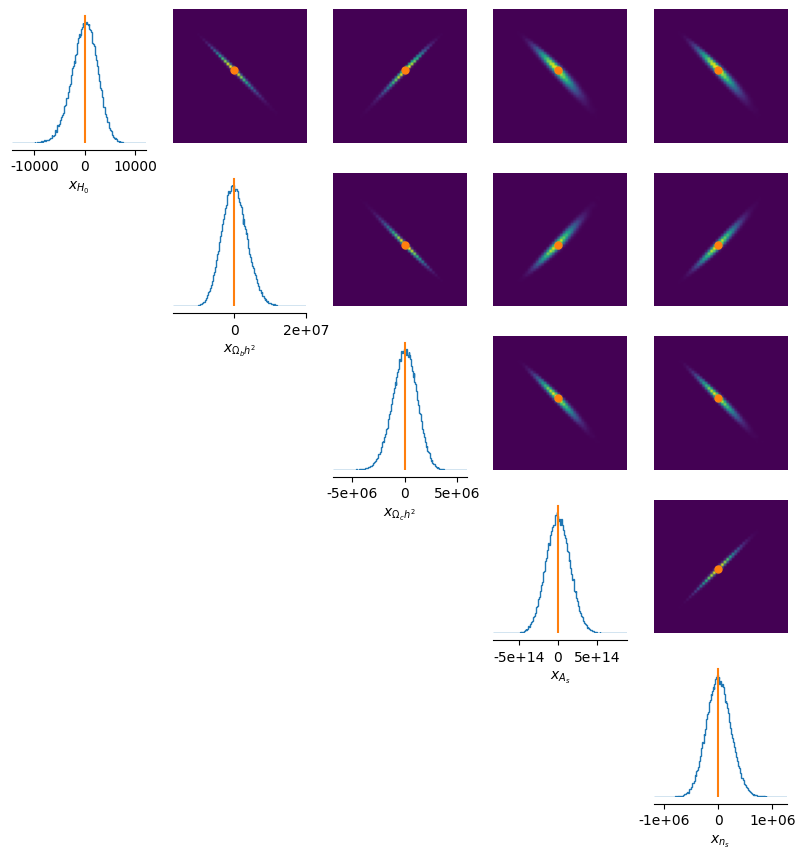

In [8]:
plot_checker(x_train_1, x_obs_1)

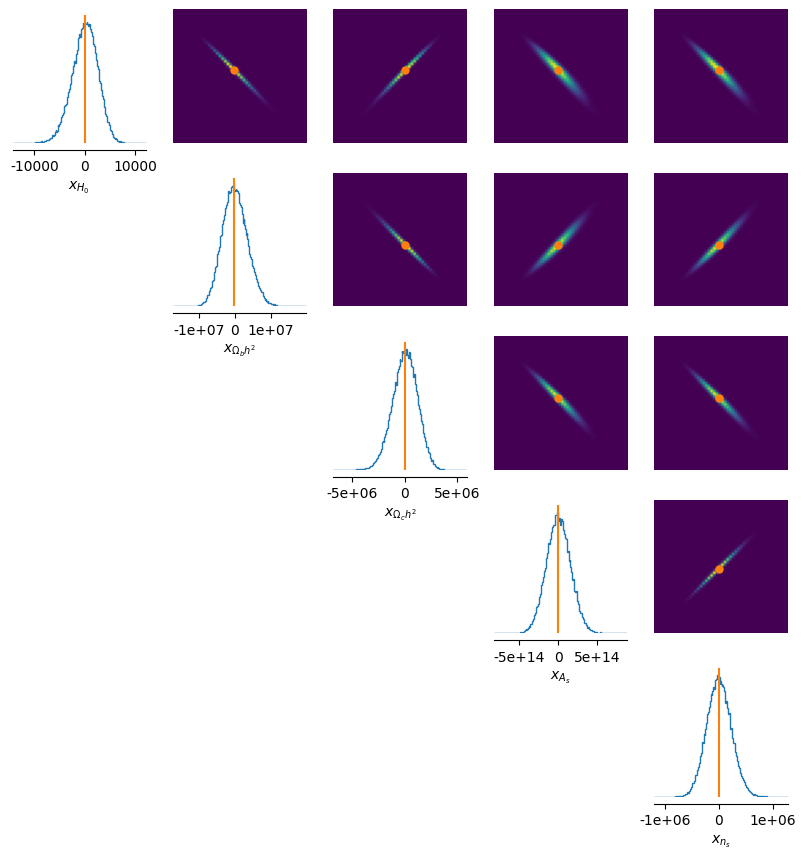

In [9]:
plot_checker(x_train_2, x_obs_2)


 Training neural network. Epochs trained: 1


 Training neural network. Epochs trained: 2


 Training neural network. Epochs trained: 3


 Training neural network. Epochs trained: 4


 Training neural network. Epochs trained: 5

...

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/data/vault/jv447/repos/Part-III-Research-Project/sbi-logs/NPE_C/2026-04-05T20_36_36.721120' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.



Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([ 1.8259e+01,  2.7598e+03,  9.4160e+03, -5.2163e+11, -2.5927e+02])


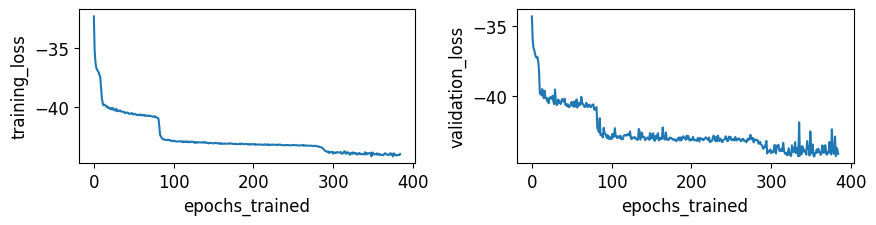

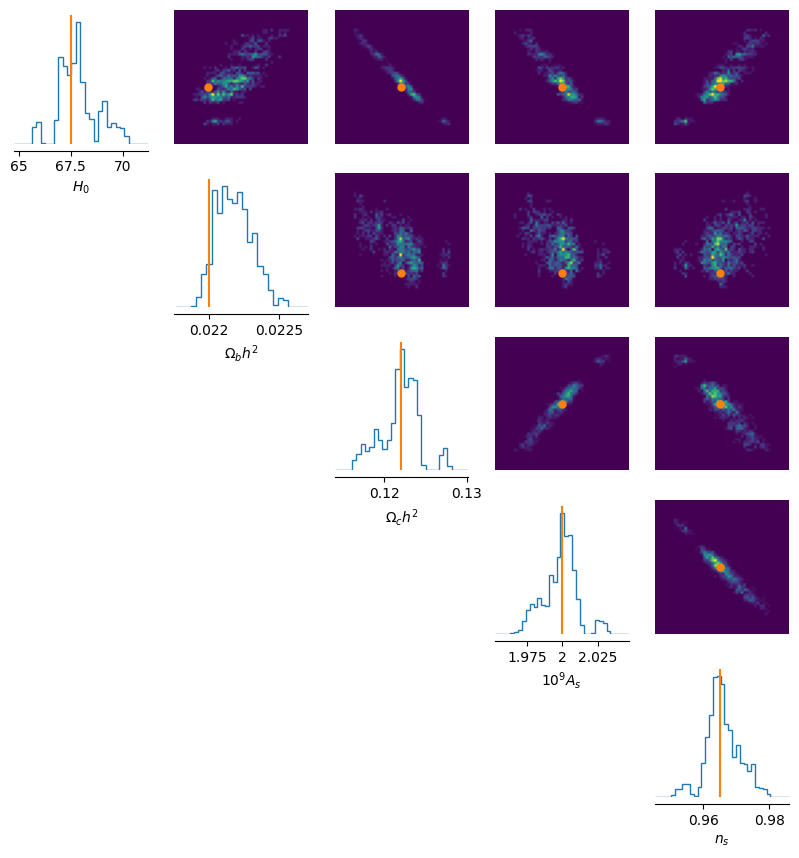

In [10]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(
    x_train_1, theta, x_obs_1, prior, verbose=True, max_epoch=1000, true_val=theta_true
)


 Training neural network. Epochs trained: 1


 Training neural network. Epochs trained: 2


 Training neural network. Epochs trained: 3


 Training neural network. Epochs trained: 4


 Training neural network. Epochs trained: 5

...

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/data/vault/jv447/repos/Part-III-Research-Project/sbi-logs/NPE_C/2026-04-05T22_58_01.200159' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.



Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([ 4.8314e+01, -5.0971e+04,  2.1389e+04, -2.1111e+12, -3.3569e+03])


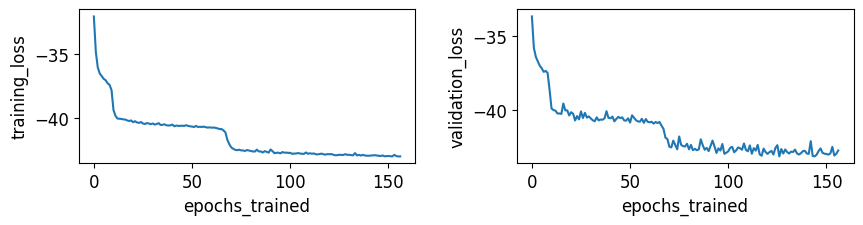

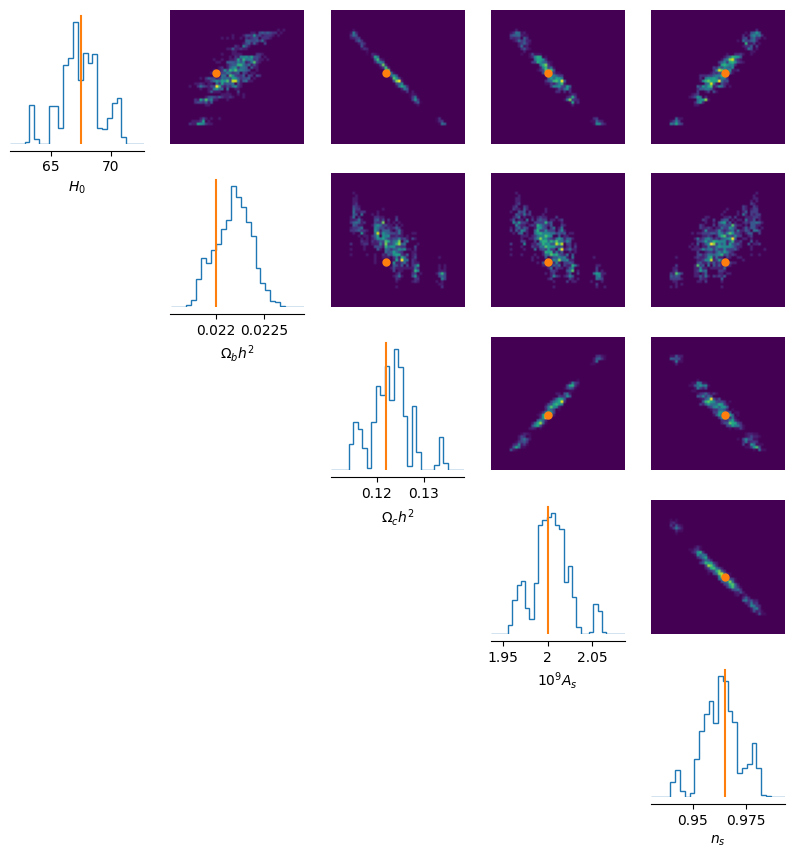

In [11]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(
    x_train_2, theta, x_obs_2, prior, verbose=True, max_epoch=1000, true_val=theta_true
)

##### In future add some posterior checks here

#### Saving Results

In [12]:
results = {
    "samples1":          samples1,          # posterior samples (N, 5) — null split
    "samples2":          samples2,          # posterior samples (N, 5) — systematic split
    "posterior1_mcmc":   posterior1_mcmc,
    "posterior1_direct": posterior1_direct,
    "posterior2_mcmc":   posterior2_mcmc,
    "posterior2_direct": posterior2_direct,
    "inference1":        inference1,        # NPE trained on beam_base
    "inference2":        inference2,        # NPE trained on beam_systematic
    "prior":             prior,
    "theta":             theta,             # training theta (N, 5)
    "x_train_1":         x_train_1,         # training summaries, null beam
    "x_train_2":         x_train_2,         # training summaries, systematic beam
    "x_obs_1":           x_obs_1,           # observed summary, null beam
    "x_obs_2":           x_obs_2,           # observed summary, systematic beam
    "nl_base":           nl_base,           # noise spectrum (consistent throughout)
    "beam_base":         beam_base,         # null beam FWHM (arcmin)
    "beam_systematic":   beam_systematic,   # 1.2x beam FWHM (arcmin)
    "TRUE_SEED_CMB":     TRUE_SEED_CMB,
    "TRUE_SEED_NOISE":   TRUE_SEED_NOISE,
    # Compressor saved as arrays — reconstruct with make_compressor() after loading
    "fiducial":          fiducial,          # fiducial C_ell spectrum (numpy)
    "cov":               cov,               # diagonal covariance (numpy)
    "derivs":            derivs,            # MOPED derivative vectors (numpy)
    "theta_true":        theta_true,        # fiducial cosmology (5,)
    "unique_seeds":      unique_seeds,
}

fname = "cmb_test_beam_point1_percent_100000.pt"
torch.save(results, fname)


/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/torch/serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


### KL Section

#### Load Results

In [4]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior",
        "theta",
        "x_train_1", "x_train_2",
        "x_obs_1", "x_obs_2",
        "nl_base",
        "beam_base", "beam_systematic",
        "TRUE_SEED_CMB", "TRUE_SEED_NOISE",
        "fiducial", "cov", "derivs",
        "theta_true", "unique_seeds",
    ]

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [5]:
fname = "cmb_test_beam_point1_percent_100000.pt"

res = load_results_file(fname)

(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior,
 theta,
 x_train_1, x_train_2,
 x_obs_1, x_obs_2,
 nl_base,
 beam_base, beam_systematic,
 TRUE_SEED_CMB, TRUE_SEED_NOISE,
 fiducial, cov, derivs,
 theta_true, unique_seeds,
) = extract_results(res)

# Reconstruct the compressor closure from its saved arrays
my_compressor = make_compressor(fiducial, cov, derivs)


/tmp/ipykernel_1549841/314239381.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


In [6]:
# Resample with many more draws using the direct (i.i.d.) sampler
# The saved MCMC samples (1,000) are too few for clean 5D marginals
samples1 = posterior1_direct.sample((100_000,), x=x_obs_1)
samples2 = posterior2_direct.sample((100_000,), x=x_obs_2)
print(f"Resampled: {samples1.shape[0]} null, {samples2.shape[0]} systematic")

  0%|          | 0/100000 [00:00<?, ?it/s]

/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


  0%|          | 0/100000 [00:00<?, ?it/s]

Resampled: 100000 null, 100000 systematic


#### Plot posteriors overlayed

#### After April 9 Meeting:

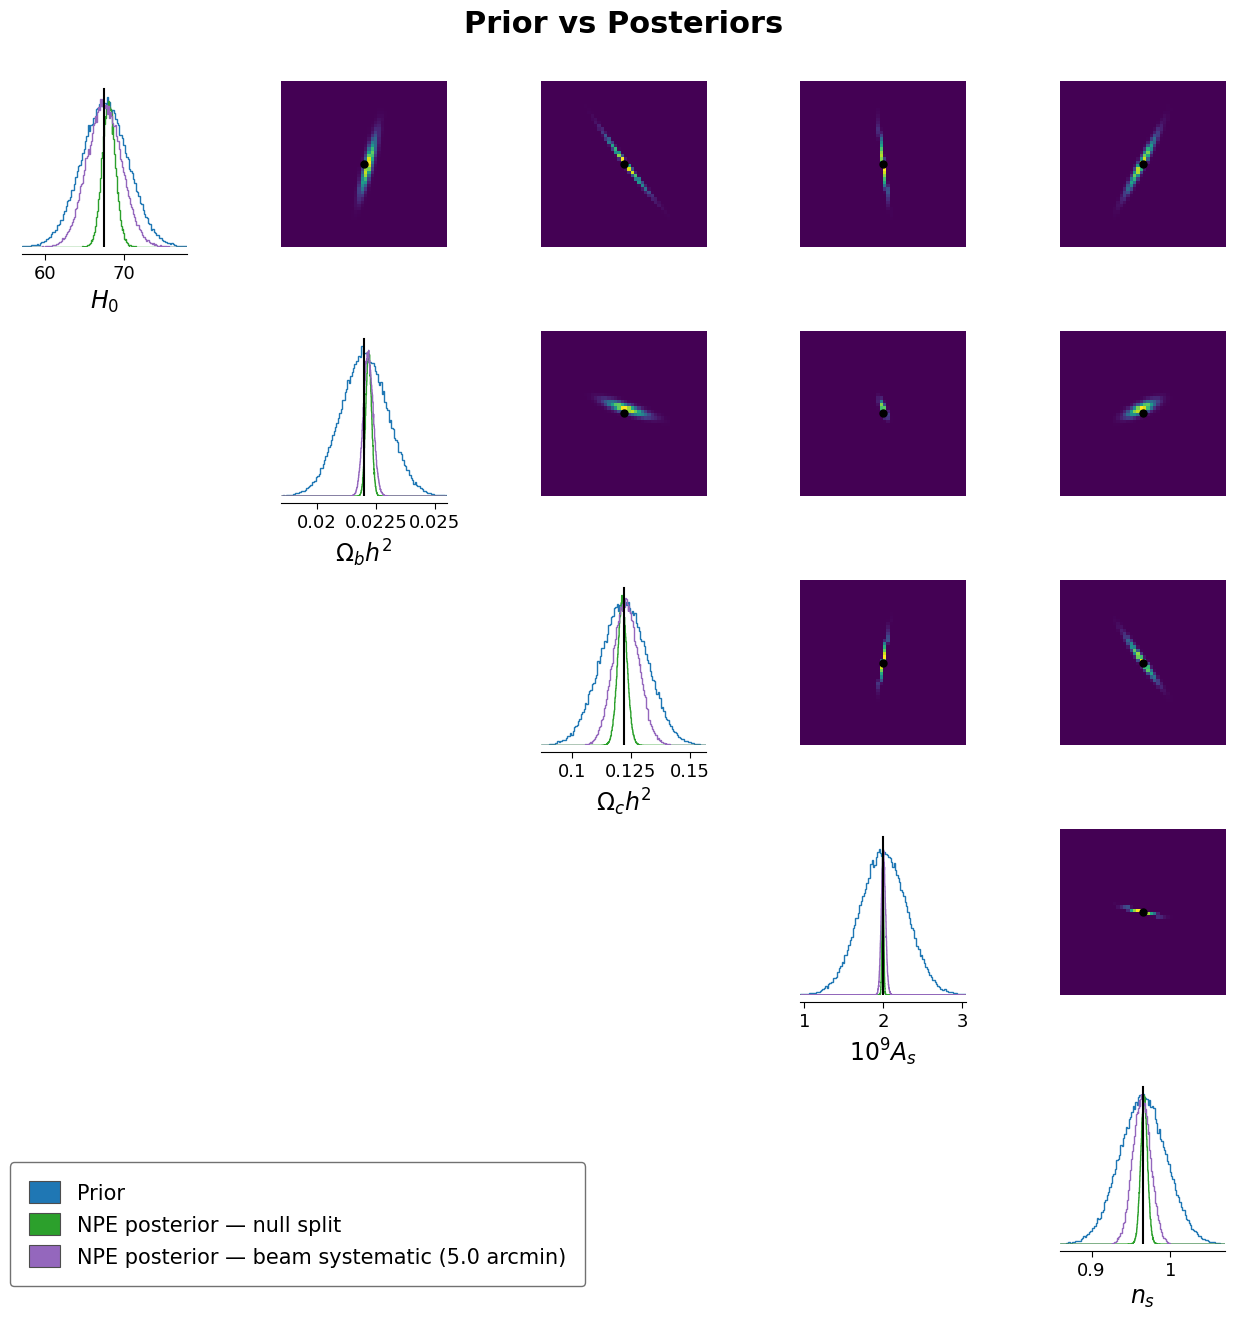

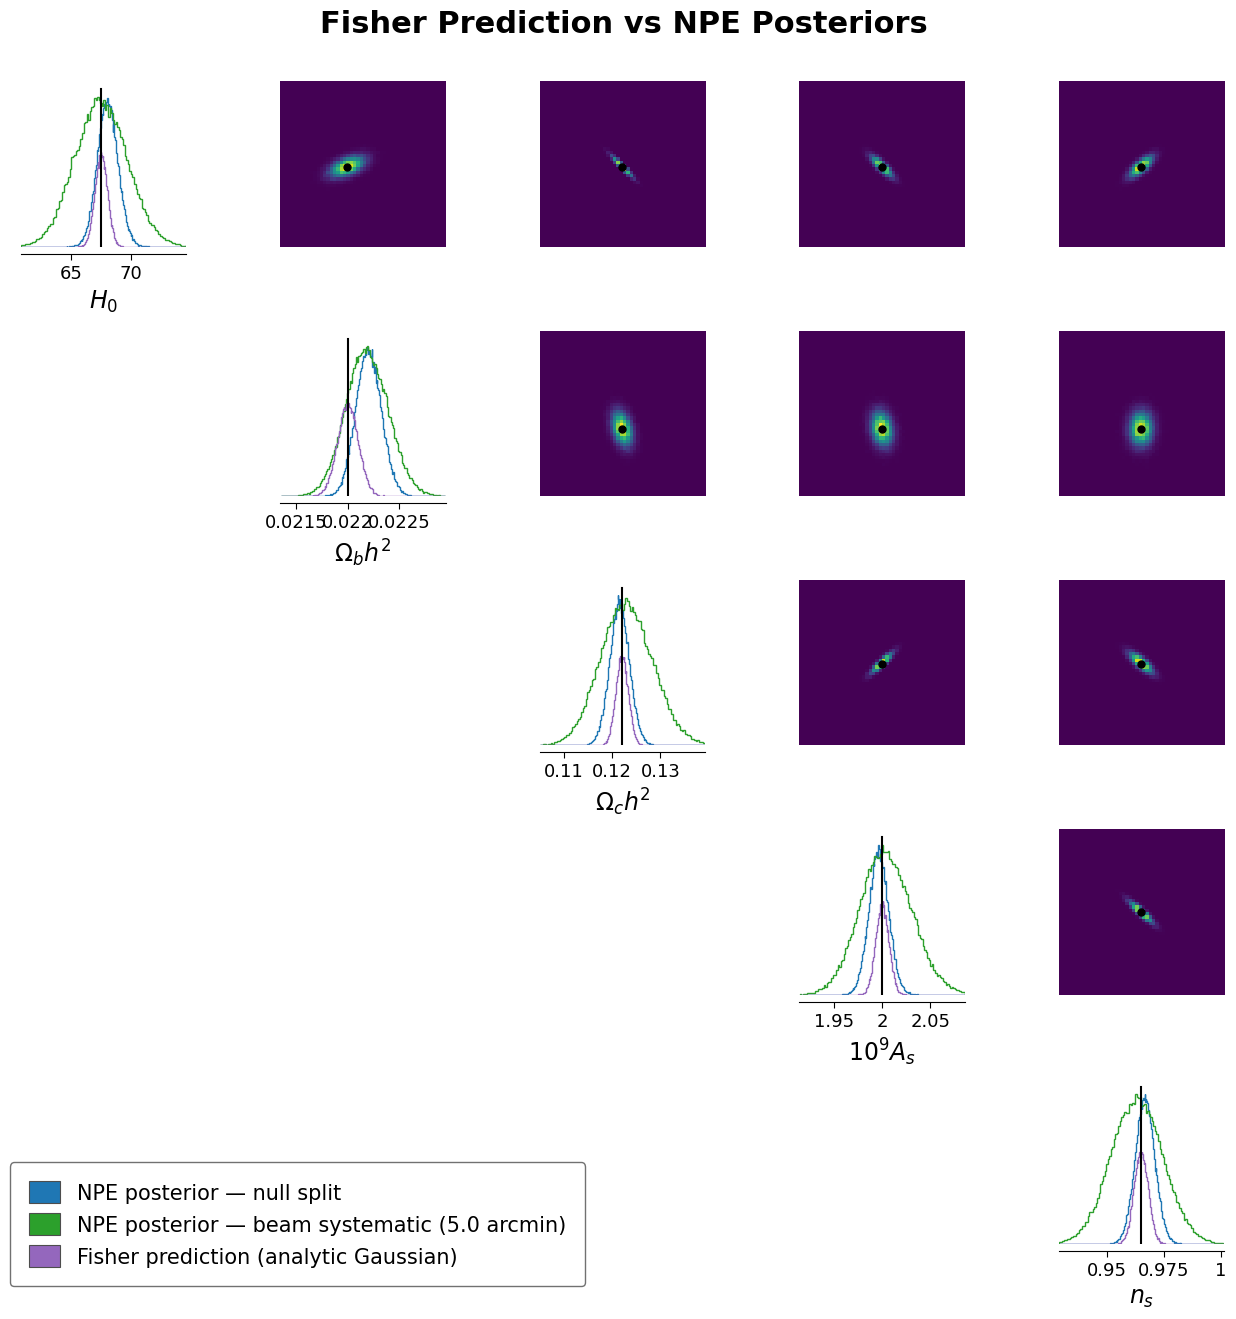


Parameter 1σ widths  (A_s in units of 10^9 A_s):
Parameter                Fisher σ   NPE σ (null)   NPE σ (sys)
───────────────────────────────────────────────────────────────
$H_0$                       0.523         0.8587         2.169
$\Omega_b h^2$          0.0001019      0.0001231     0.0002066
$\Omega_c h^2$           0.001298       0.002084      0.005468
$10^9 A_s$               0.006803        0.01037       0.02728
$n_s$                     0.00312       0.004391       0.01144


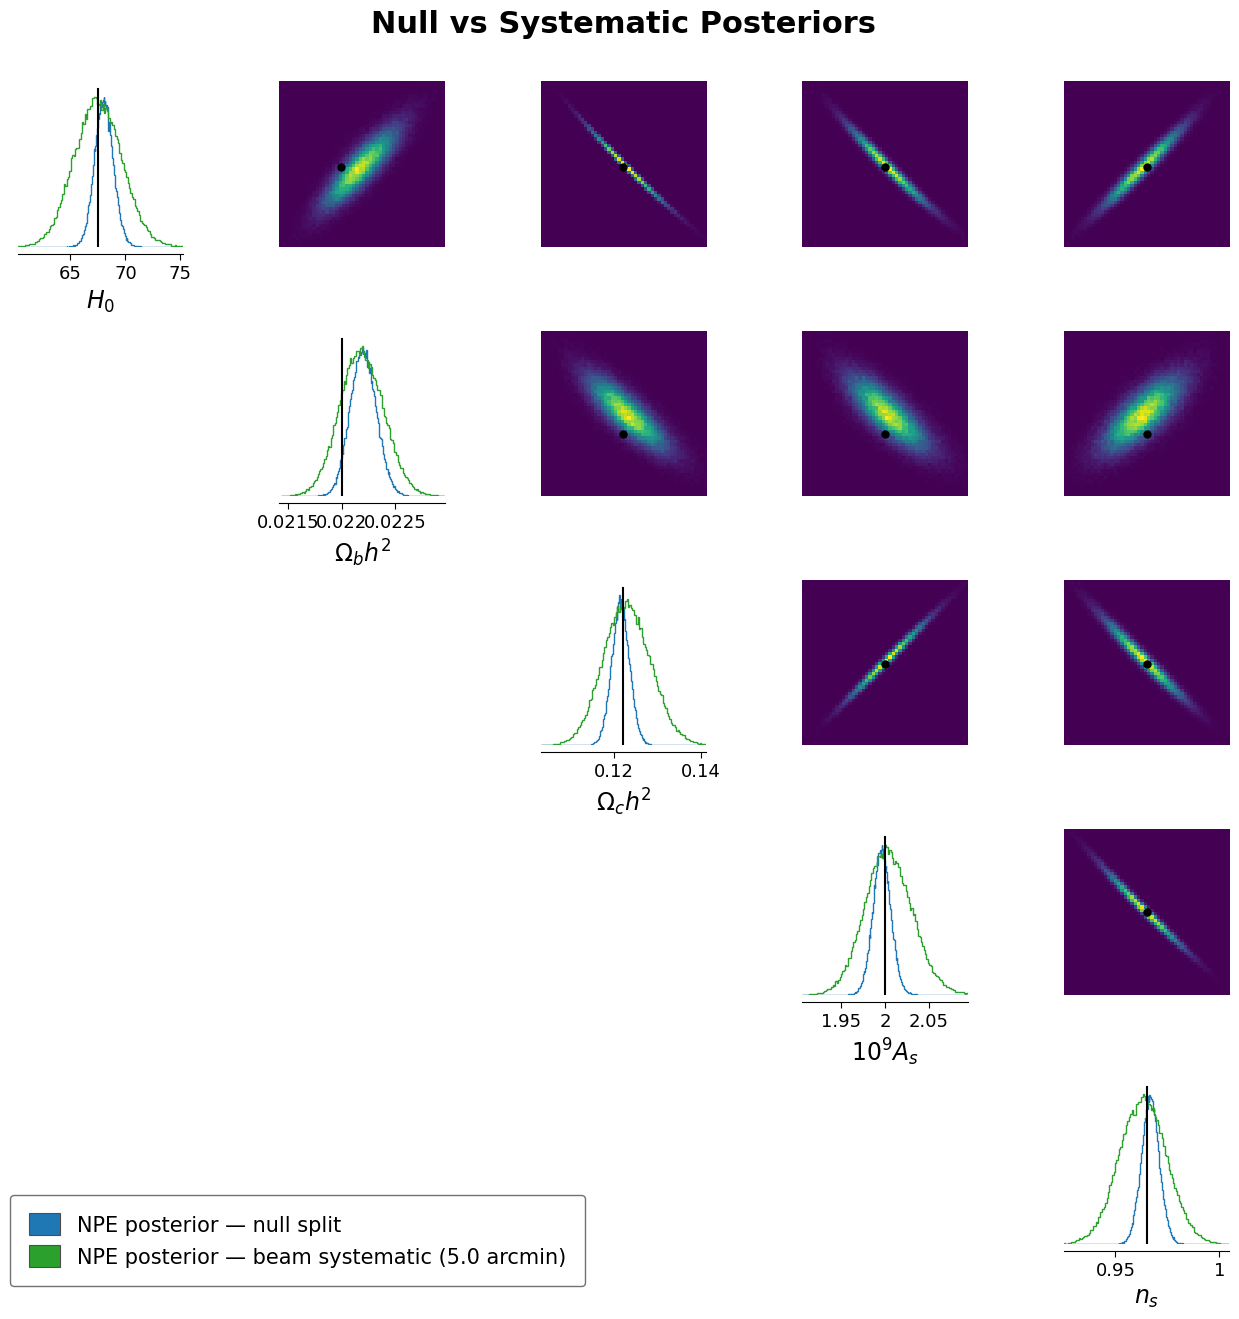

In [7]:
# ============================================================
# After April 9 Meeting — Prior/Posterior diagnostic plots
#
# Will's two asks (split into two separate pairplots):
#   Plot 1: Prior vs both posteriors   (how much is learned?)
#   Plot 2: Fisher prediction vs both posteriors  (NPE validation)
# ============================================================

import matplotlib as mpl
import matplotlib.patches as mpatches

# RC settings applied only inside each pairplot call via rc_context
_RC = {
    "font.size":       16,
    "axes.labelsize":  18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.titlesize":  16,
}

PARAM_LABELS = [
    r"$H_0$",
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$10^9 A_s$",
    r"$n_s$",
]


# ------------------------------------------------------------------
# Helper: enforce font sizes on all axes after sbi renders them
# ------------------------------------------------------------------
def _style_axes(axes):
    """Iterate the pairplot axes grid and set presentation-quality font sizes."""
    for row in axes:
        for ax in row:
            if ax is None:
                continue
            ax.tick_params(axis="both", labelsize=13, length=4, width=0.8)
            ax.xaxis.label.set_size(17)
            ax.yaxis.label.set_size(17)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)


# ------------------------------------------------------------------
# Helper: figure-level legend in the bottom-left corner
# ------------------------------------------------------------------
def _add_legend(fig, entries):
    """
    Add a clean legend using coloured patches.
    entries: list of (color, label) tuples.
    """
    handles = [
        mpatches.Patch(facecolor=c, edgecolor="0.3", linewidth=0.8, label=lbl)
        for c, lbl in entries
    ]
    leg = fig.legend(
        handles=handles,
        fontsize=15,
        frameon=True,
        facecolor="white",
        edgecolor="0.3",
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        borderpad=0.9,
        handlelength=1.5,
        handleheight=1.2,
    )
    leg.get_frame().set_linewidth(1.0)


# ------------------------------------------------------------------
# Helper: A_s scaling for display only (index 3 → ×10^9)
# ------------------------------------------------------------------
def _scale_As(s):
    """Return a float32 tensor with A_s (col 3) scaled by 1e9 for display."""
    if not torch.is_tensor(s):
        s = torch.tensor(np.asarray(s, dtype=np.float32))
    s = s.clone().float()
    s[:, 3] = s[:, 3] * 1e9
    return s


# ------------------------------------------------------------------
# Helper: prior axis limits in display units
# ------------------------------------------------------------------
def _prior_limits(prior, n_sigma=3.5):
    """Return ±n_sigma limits per parameter (A_s already scaled by 1e9)."""
    mean = prior.loc.numpy().copy()
    std  = prior.covariance_matrix.diagonal().sqrt().numpy().copy()
    mean[3] *= 1e9
    std[3]  *= 1e9
    return [[mean[i] - n_sigma * std[i], mean[i] + n_sigma * std[i]] for i in range(5)]


def _sys_label(beam_systematic):
    if beam_systematic is not None:
        return f"NPE posterior — beam systematic ({beam_systematic:.1f} arcmin)"
    return "NPE posterior — systematic split"


# ------------------------------------------------------------------
# Fisher information: analytic posterior prediction
# ------------------------------------------------------------------
def compute_fisher_posterior(derivs, cov, prior):
    """
    MOPED Fisher matrix:  F = derivs @ diag(1/cov) @ derivs.T   shape (5,5)
    Posterior covariance: C_post = (F + C_prior^{-1})^{-1}
    """
    F           = (derivs / cov) @ derivs.T        # shape: (5, 5)
    prior_cov   = prior.covariance_matrix.numpy()  # shape: (5, 5)
    C_prior_inv = np.linalg.inv(prior_cov)
    C_post      = np.linalg.inv(F + C_prior_inv)
    return F, C_post


# ------------------------------------------------------------------
# Plot 1 — Prior vs both posteriors
# ------------------------------------------------------------------
def plot_prior_vs_posteriors(samples1, samples2, prior, theta_true,
                              beam_systematic=None, n_prior_samples=100000):
    """
    Shows how much the posteriors shrink relative to the prior.
    Grey=Prior, Blue=Null posterior, Orange=Systematic posterior.
    """
    prior_samples      = prior.sample((n_prior_samples,))  # shape: (N, 5)
    prior_plot         = _scale_As(prior_samples)
    post1_plot         = _scale_As(samples1)
    post2_plot         = _scale_As(samples2)

    theta_true_plot    = np.asarray(theta_true, dtype=float).copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[prior_plot, post1_plot, post2_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=_prior_limits(prior),
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "Prior"),
        ("#2ca02c", "NPE posterior — null split"),
        ("#9467bd", _sys_label(beam_systematic)),
    ])
    fig.suptitle("Prior vs Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# Plot 2 — Fisher-predicted posterior vs both NPE posteriors
# ------------------------------------------------------------------
def plot_fisher_vs_posteriors(samples1, samples2, prior, theta_true,
                               derivs, cov, beam_systematic=None,
                               n_fisher_samples=50000):
    """
    Compares the analytic Fisher prediction against both NPE posteriors.
    Agreement of blue/green validates the NPE on the null split.
    Green=Fisher, Blue=Null NPE, Orange=Systematic NPE.
    """
    F, C_post = compute_fisher_posterior(derivs, cov, prior)

    theta_true_np  = np.asarray(theta_true, dtype=float)
    fisher_dist    = MultivariateNormal(
        loc=torch.tensor(theta_true_np, dtype=torch.float32),
        covariance_matrix=torch.tensor(C_post, dtype=torch.float32),
    )
    fisher_samples = fisher_dist.sample((n_fisher_samples,))  # shape: (N, 5)

    post1_plot  = _scale_As(samples1)
    post2_plot  = _scale_As(samples2)
    fisher_plot = _scale_As(fisher_samples)

    theta_true_plot    = theta_true_np.copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    # Tight limits: ±4.5σ around the combined posterior+Fisher cloud
    all_np = np.concatenate([post1_plot.numpy(), post2_plot.numpy(),
                              fisher_plot.numpy()], axis=0)
    means  = all_np.mean(axis=0)
    stds   = all_np.std(axis=0)
    tight_limits = [[means[i] - 4.5*stds[i], means[i] + 4.5*stds[i]] for i in range(5)]

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot, fisher_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=tight_limits,
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — null split"),
        ("#2ca02c", _sys_label(beam_systematic)),
        ("#9467bd", "Fisher prediction (analytic Gaussian)"),
    ])
    fig.suptitle("Fisher Prediction vs NPE Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # 1σ comparison table
    print("\nParameter 1σ widths  (A_s in units of 10^9 A_s):")
    print(f"{'Parameter':<20} {'Fisher σ':>12} {'NPE σ (null)':>14} {'NPE σ (sys)':>13}")
    print("─" * 63)
    fisher_stds = np.sqrt(np.diag(C_post))
    npe1_stds   = post1_plot.numpy().std(axis=0)
    npe2_stds   = post2_plot.numpy().std(axis=0)
    for i, lbl in enumerate(PARAM_LABELS):
        f_s = fisher_stds[i] * (1e9 if i == 3 else 1.0)
        print(f"{lbl:<20} {f_s:>12.4g} {npe1_stds[i]:>14.4g} {npe2_stds[i]:>13.4g}")

    return F, C_post



# ------------------------------------------------------------------
# Plot 3 — Null posterior vs systematic posterior only
# ------------------------------------------------------------------
def plot_posteriors_overlaid(samples1, samples2, prior, theta_true,
                              beam_systematic=None):
    """
    Pairplot showing only the two posteriors overlaid.
    Blue=Null, Orange=Systematic.
    Limits set tightly around the posteriors (not the prior).
    """
    post1_plot = _scale_As(samples1)
    post2_plot = _scale_As(samples2)

    theta_true_plot    = np.asarray(theta_true, dtype=float).copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    # Tight limits around both posteriors combined
    all_np = np.concatenate([post1_plot.numpy(), post2_plot.numpy()], axis=0)
    means  = all_np.mean(axis=0)
    stds   = all_np.std(axis=0)
    tight_limits = [[means[i] - 4.5*stds[i], means[i] + 4.5*stds[i]] for i in range(5)]

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=tight_limits,
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — null split"),
        ("#2ca02c", _sys_label(beam_systematic)),
    ])
    fig.suptitle("Null vs Systematic Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_prior_vs_posteriors(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)

F, C_post = plot_fisher_vs_posteriors(
    samples1, samples2, prior, theta_true, derivs, cov,
    beam_systematic=beam_systematic,
)

plot_posteriors_overlaid(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)


Note: you may need to restart the kernel to use updated packages.
Removed no burn in
Removed no burn in
Removed no burn in


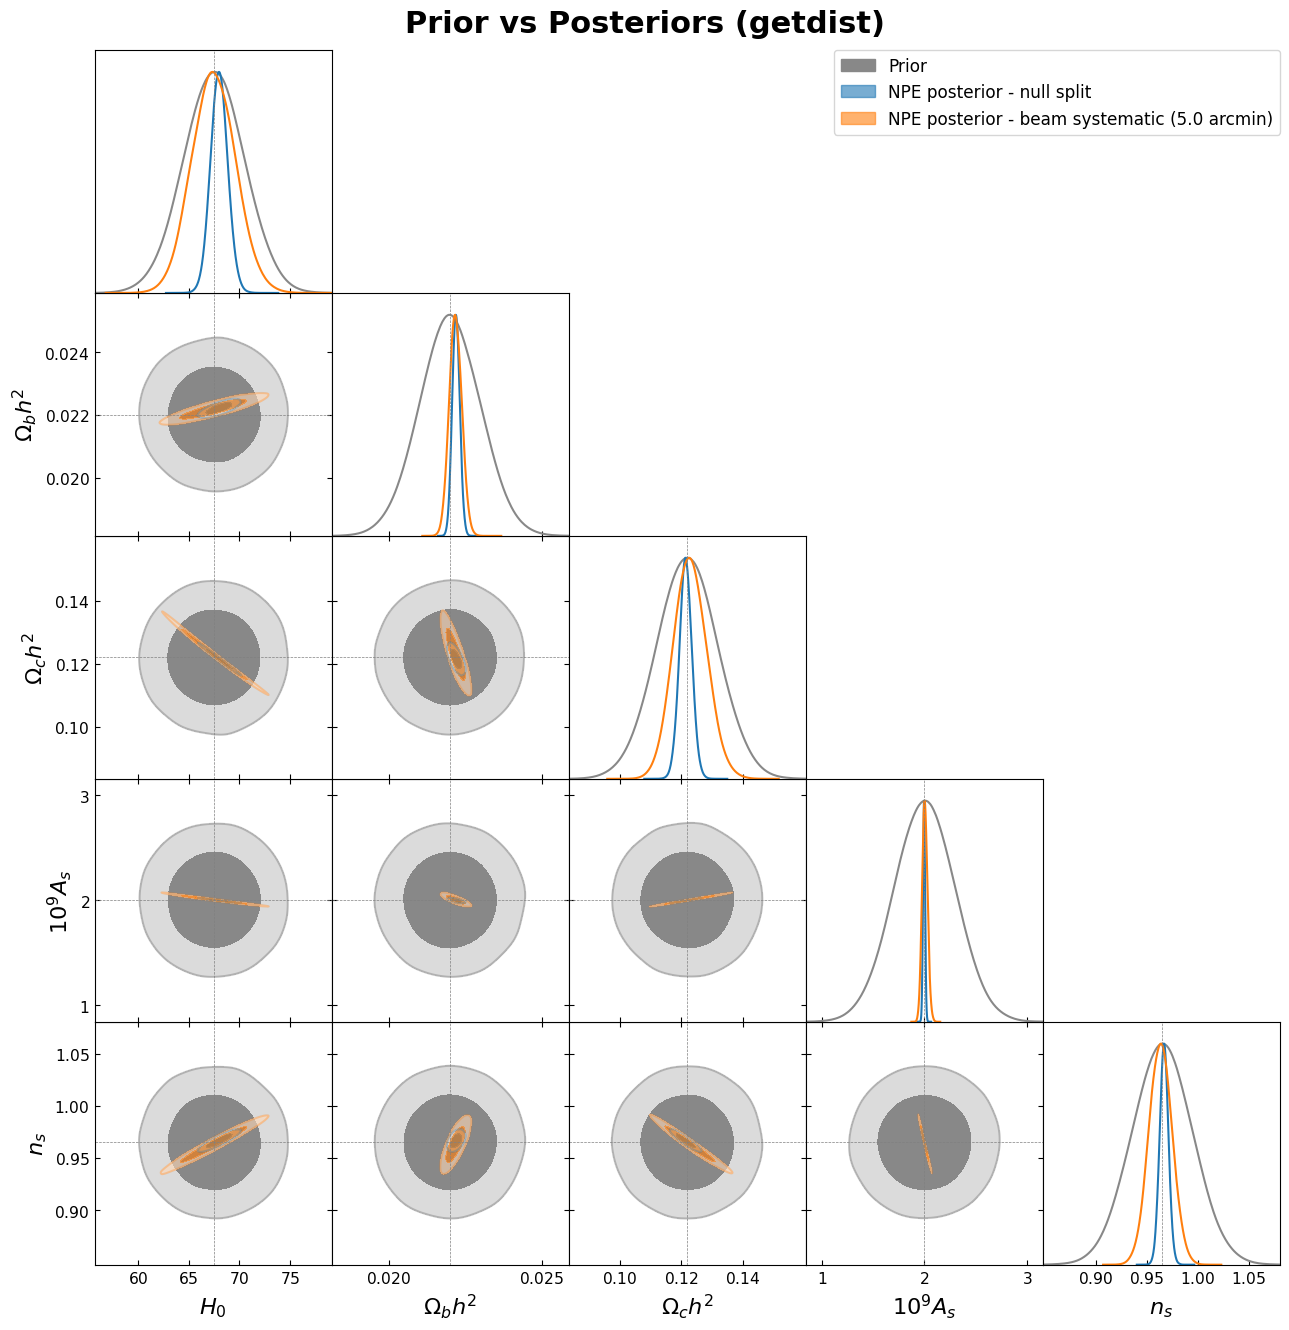

Removed no burn in
Removed no burn in
Removed no burn in


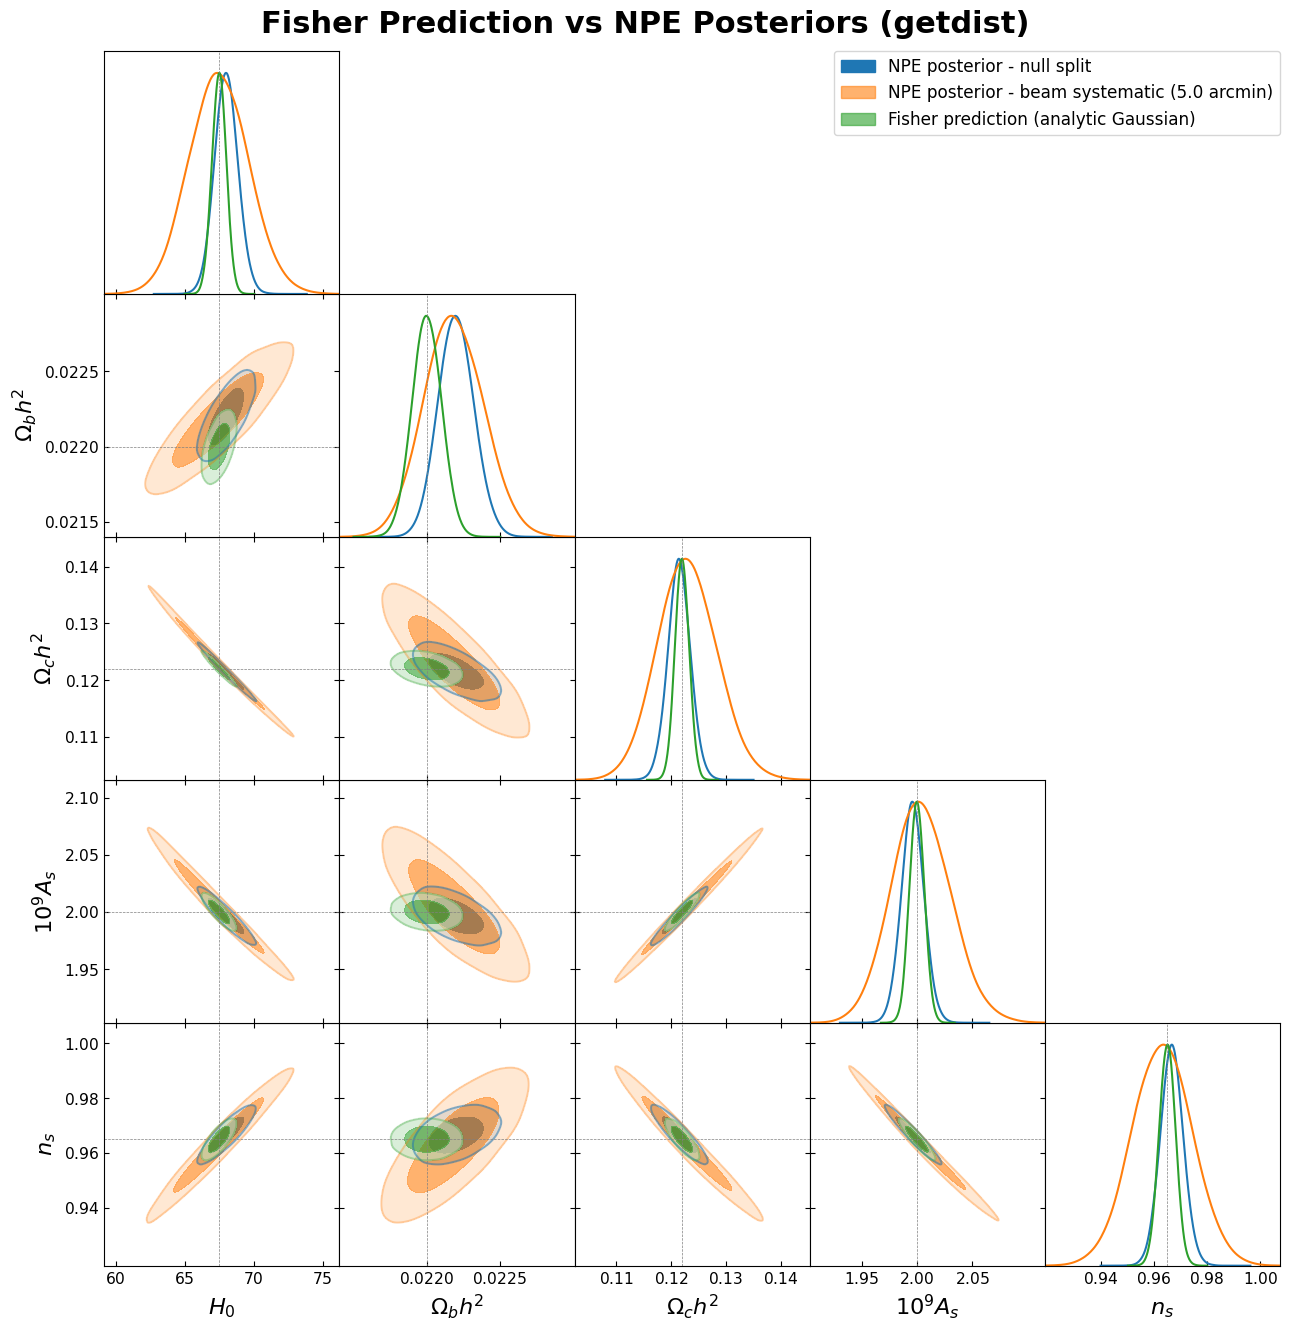

Removed no burn in
Removed no burn in


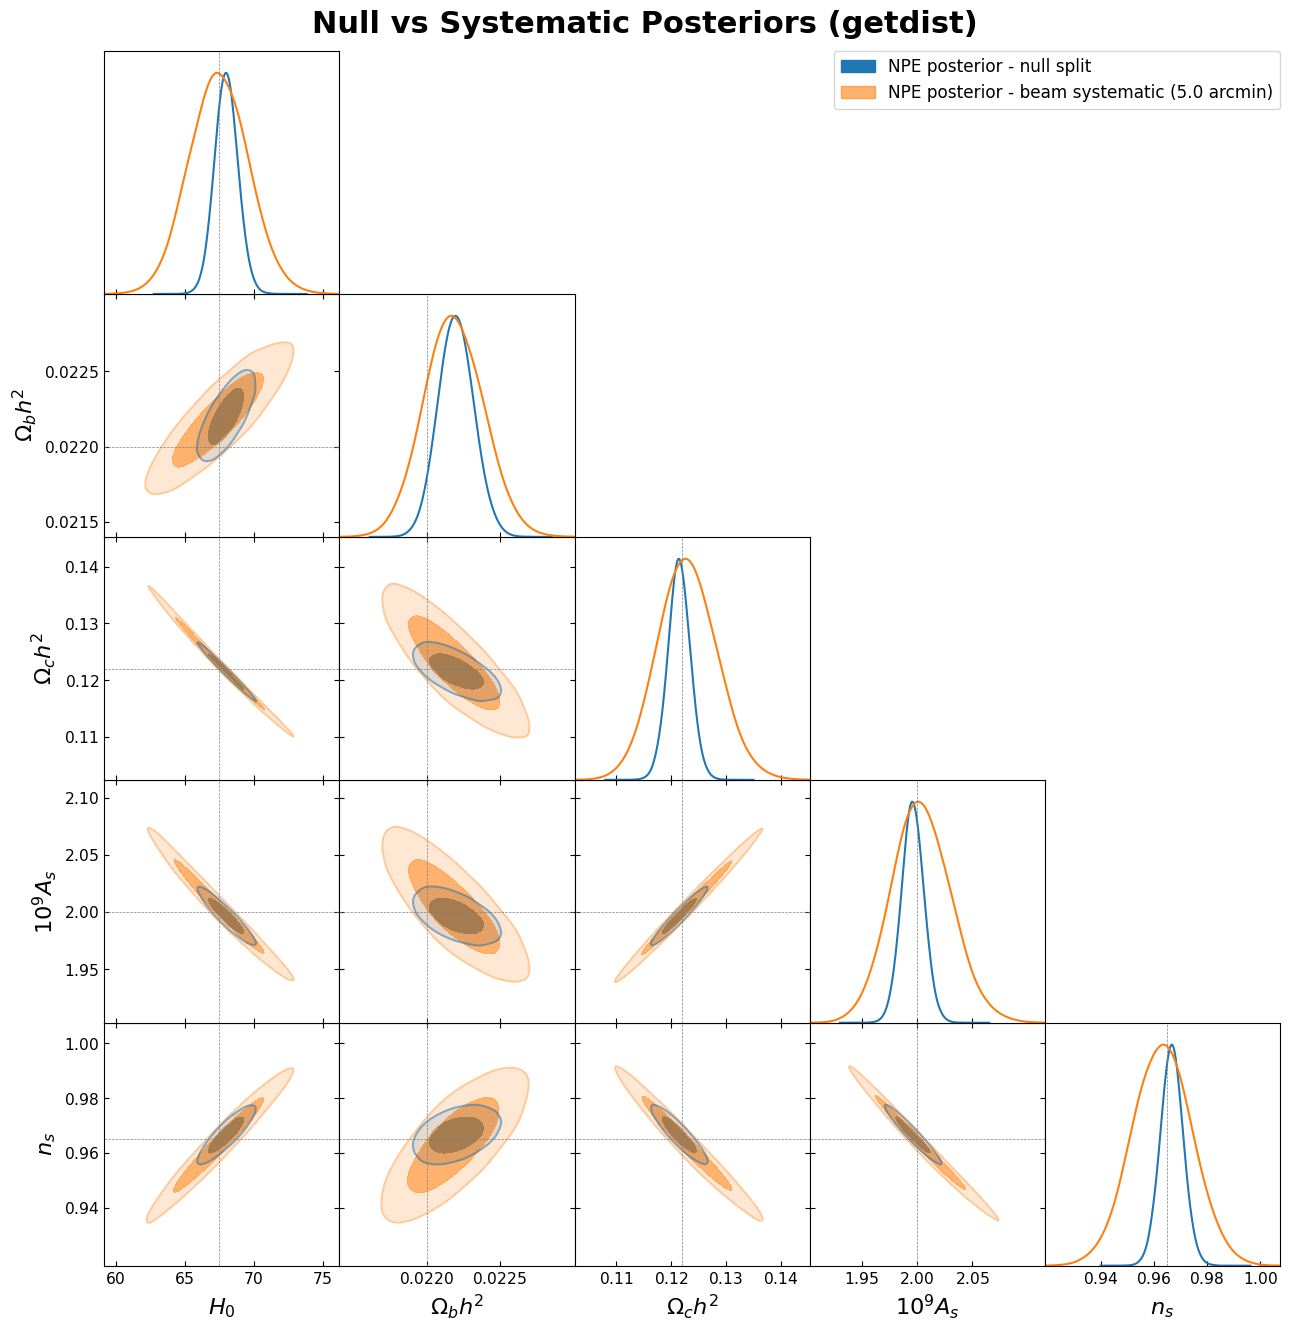

In [8]:
# ============================================================
# getdist versions of the three diagnostic plots
# (in response to Will's Apr-14 suggestion to use corner/getdist)
#
# Keeps the sbi.pairplot cell above for reference;
# this cell is the presentation-quality version.
# ============================================================

# Install getdist on first run (comment out after)
%pip install --quiet getdist

from getdist import MCSamples, plots as gd_plots

# Parameter internal names and LaTeX labels (A_s shown as 10^9 A_s)
GD_NAMES  = ['H0', 'ombh2', 'omch2', 'As_scaled', 'ns']
GD_LABELS = ['H_0', r'\Omega_b h^2', r'\Omega_c h^2', r'10^9 A_s', 'n_s']


def _to_mcsamples(samples, label):
    """Convert a (N, 5) tensor/array to an MCSamples with A_s scaled by 1e9."""
    arr = samples.numpy() if torch.is_tensor(samples) else np.asarray(samples)
    arr = arr.astype(float).copy()
    arr[:, 3] *= 1e9   # A_s display rescale
    return MCSamples(
        samples=arr,
        names=GD_NAMES,
        labels=GD_LABELS,
        label=label,
    )


def _make_plotter(width_inch=13):
    """Return a getdist subplot plotter with presentation-quality settings."""
    g = gd_plots.get_subplot_plotter(width_inch=width_inch)
    # Peak=1 normalisation for 1D marginals (Will's request so PDFs
    # can be directly shape-compared without sample-count bias)
    g.settings.norm_1d_density = True
    g.settings.alpha_filled_add = 0.6
    g.settings.axes_fontsize    = 13
    g.settings.lab_fontsize     = 18
    g.settings.legend_fontsize  = 14
    g.settings.linewidth        = 2.0
    g.settings.linewidth_contour = 2.0
    g.settings.solid_contour_palefactor = 0.7
    return g


def _theta_true_markers(theta_true):
    """Dict of vertical/horizontal marker lines at the true cosmology."""
    t = np.asarray(theta_true, dtype=float).copy()
    t[3] *= 1e9
    return dict(zip(GD_NAMES, t))


def _sys_label_gd(beam_systematic):
    if beam_systematic is not None:
        return f'NPE posterior - beam systematic ({beam_systematic:.1f} arcmin)'
    return 'NPE posterior - systematic split'


# ------------------------------------------------------------------
# Plot 1 (getdist) - Prior vs both posteriors
# ------------------------------------------------------------------
def plot_prior_vs_posteriors_gd(samples1, samples2, prior, theta_true,
                                 beam_systematic=None, n_prior_samples=100_000):
    mc_prior = _to_mcsamples(prior.sample((n_prior_samples,)), 'Prior')
    mc_null  = _to_mcsamples(samples1, 'NPE posterior - null split')
    mc_sys   = _to_mcsamples(samples2, _sys_label_gd(beam_systematic))

    g = _make_plotter()
    g.triangle_plot(
        [mc_prior, mc_null, mc_sys],
        filled=True,
        contour_colors=['#888888', '#1f77b4', '#ff7f0e'],
        markers=_theta_true_markers(theta_true),
        legend_loc='upper right',
    )
    plt.suptitle('Prior vs Posteriors (getdist)', fontsize=22, fontweight='bold', y=1.02)
    plt.show()


# ------------------------------------------------------------------
# Plot 2 (getdist) - Fisher prediction vs both NPE posteriors
# ------------------------------------------------------------------
def plot_fisher_vs_posteriors_gd(samples1, samples2, prior, theta_true,
                                  derivs, cov, beam_systematic=None,
                                  n_fisher_samples=50_000):
    F, C_post = compute_fisher_posterior(derivs, cov, prior)

    theta_np  = np.asarray(theta_true, dtype=float)
    fisher_dist = MultivariateNormal(
        loc=torch.tensor(theta_np, dtype=torch.float32),
        covariance_matrix=torch.tensor(C_post, dtype=torch.float32),
    )
    fisher_samples = fisher_dist.sample((n_fisher_samples,))

    mc_null   = _to_mcsamples(samples1,       'NPE posterior - null split')
    mc_sys    = _to_mcsamples(samples2,       _sys_label_gd(beam_systematic))
    mc_fisher = _to_mcsamples(fisher_samples, 'Fisher prediction (analytic Gaussian)')

    g = _make_plotter()
    g.triangle_plot(
        [mc_null, mc_sys, mc_fisher],
        filled=True,
        contour_colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
        markers=_theta_true_markers(theta_true),
        legend_loc='upper right',
    )
    plt.suptitle('Fisher Prediction vs NPE Posteriors (getdist)',
                 fontsize=22, fontweight='bold', y=1.02)
    plt.show()
    return F, C_post


# ------------------------------------------------------------------
# Plot 3 (getdist) - Both posteriors overlaid
# ------------------------------------------------------------------
def plot_posteriors_overlaid_gd(samples1, samples2, prior, theta_true,
                                 beam_systematic=None):
    mc_null = _to_mcsamples(samples1, 'NPE posterior - null split')
    mc_sys  = _to_mcsamples(samples2, _sys_label_gd(beam_systematic))

    g = _make_plotter()
    g.triangle_plot(
        [mc_null, mc_sys],
        filled=True,
        contour_colors=['#1f77b4', '#ff7f0e'],
        markers=_theta_true_markers(theta_true),
        legend_loc='upper right',
    )
    plt.suptitle('Null vs Systematic Posteriors (getdist)',
                 fontsize=22, fontweight='bold', y=1.02)
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_gd(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)
_ = plot_fisher_vs_posteriors_gd(
    samples1, samples2, prior, theta_true, derivs, cov,
    beam_systematic=beam_systematic,
)
plot_posteriors_overlaid_gd(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)

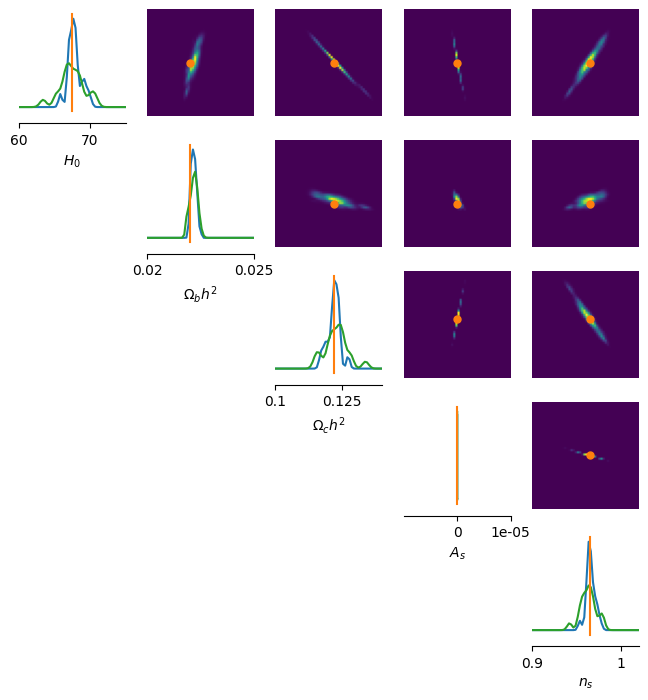

In [15]:
param_labels = [
    r"$H_0$",
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$A_s$",
    r"$n_s$",
]

# Use prior bounds as plot limits for a clean, comparable view of both posteriors
limits = [
    [60.0,   75.0  ],
    [0.020,  0.025 ],
    [0.10,   0.14  ],
    [1.5e-9, 2.5e-9],
    [0.90,   1.02  ],
]

_ = pairplot(
    samples=[samples1, samples2],
    points=theta_true,
    limits=limits,
    upper="kde",
    diag="kde",
    figsize=(8, 8),
    labels=param_labels,
)

#### Define and calculate KL

In [16]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error


def calibrate_null_dkl(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, dkl_obs):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky (seed_cmb=i), independent noise draws (seed_noise offset by 1M)
        # Both splits use the null beam — true null, no systematic
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=1, label='Observed D_KL Value')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=1, label='95% Critical Value')
    plt.ylabel("density")
    plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
    plt.legend()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


0/100


20/100


40/100


60/100


80/100


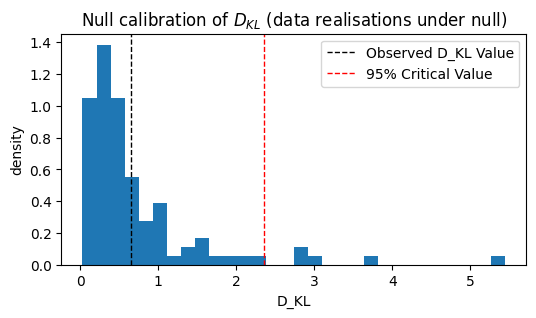

Null 95 percent critical value: 2.351121902465819
DKL observed: 0.6492918133735657


In [17]:
dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs_1, x_obs_2, n_theta=50)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior, 100, 500, my_compressor, nl_base, beam_base, dkl_obs)
print("DKL observed:", dkl_obs)


In [18]:
def calibrate_null_dkl_neat(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, dkl_obs):
    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 500 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky (seed_cmb=i), independent noise draws (seed_noise offset by 1M)
        # Both splits use the null beam — true null, no systematic
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000) # obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    # ==========================================
    # PLOTTING
    # ==========================================
    # Larger figure size and high DPI for crisp projection
    plt.figure(figsize=(8, 4.5), dpi=150)
    
    # Add a clean grid *behind* the histogram bars
    plt.gca().set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.grid(axis='x', linestyle=':', alpha=0.4)  

    # Original style: solid bars, no gaps
    plt.hist(dkls, bins=30, density=True, color='tab:blue', label=r'Null Distribution ($H_0$)')
    
    # Vertical lines
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')
    
    # Labels and Titles
    plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
    plt.ylabel("Probability Density", fontsize=14, labelpad=10)
    plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)
    
    # Tick marks: larger fonts
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Upgraded Legend
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    
    plt.tight_layout()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


0/750


500/750


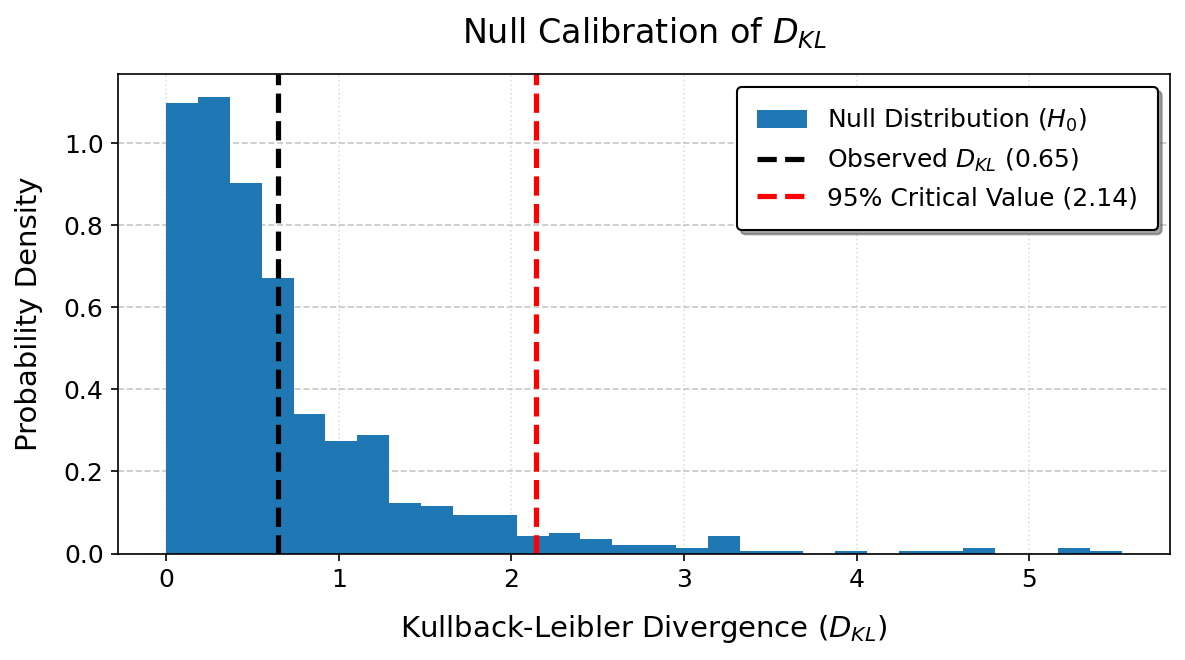

Null 95 percent critical value: 2.1401629328727694
DKL observed: 0.6492918133735657


In [19]:
dkls_neat, crit_val_95_neat = calibrate_null_dkl_neat(posterior1_direct, prior, 750, 500, my_compressor, nl_base, beam_base, dkl_obs)
print("DKL observed:", dkl_obs)


#### Perturbation Calc

In [20]:
def calibrate_null_dkl_and_perturbed(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, beam_perturbed):

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky, independent noise draws for the two null splits
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000) #obtaining summary statistics of data
        # Perturbed split 1: same sky & noise seed as x1_i, only beam changes
        x1_i_perturbed = blanket_simulator(theta_i, compressor, nl_null,
                                           beam_fwhm=beam_perturbed,
                                           seed_cmb=i, seed_noise=i + 1_000_000)
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    #plot histograms
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title(r"Perturbed calibration of $D_{KL}$ (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed


0/100


20/100


40/100


60/100


80/100


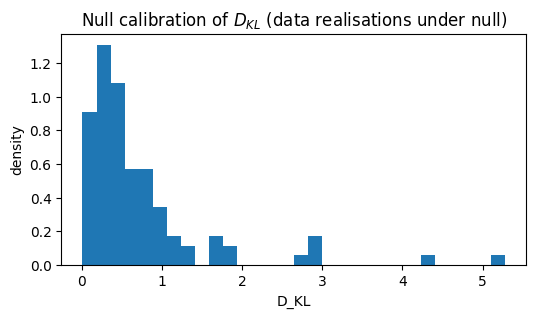

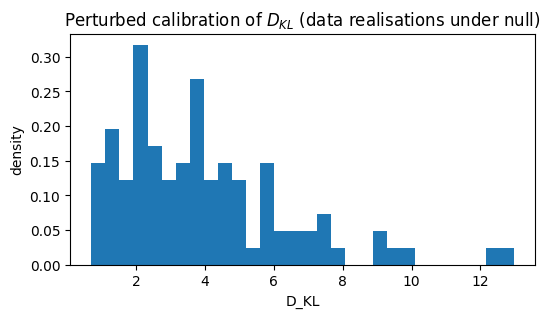

Null 95 percent critical value: 2.7256936073303217
Perturbed 95 percent critical value: 8.987439632415771


In [21]:
dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed = calibrate_null_dkl_and_perturbed(
    posterior1_direct, prior, 100, 500, my_compressor, nl_base, beam_base, beam_systematic
)


#### this needs adapting a little but is the looping through shifts to find sensitivity (get rid of all analytical stuff as not gaussian anymore)

In [22]:
def calibrate_null_dkl_and_perturb_mean(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, multiplier):

    # Build perturbed beam from multiplier
    beam_perturbed = beam_null * multiplier

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky, independent noise draws for the two null splits
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000) #obtaining summary statistics of data
        # Perturbed split 1: same sky & noise seed as x1_i, only beam changes
        x1_i_perturbed = blanket_simulator(theta_i, compressor, nl_null,
                                           beam_fwhm=beam_perturbed,
                                           seed_cmb=i, seed_noise=i + 1_000_000)
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    # new test stat
    median_perturbed = float(np.median(dkls_perturbed))

    
    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed, median_perturbed



0/200


100/200


0/200


100/200


0/200


100/200


0/200


100/200


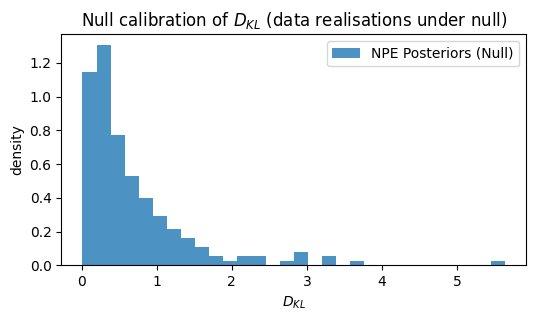

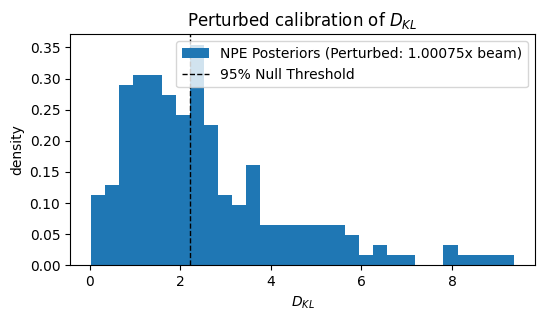

Null 95 percent critical value: 2.212030124664304
Perturbed 95 percent critical value: 6.234840655326842


In [ ]:
multipliers_to_test = [1.00075, 1.00076, 1.00077]  # sweep beam_base * x
sensitivity_threshold_reached = False

for multiplier_val in multipliers_to_test:
    results = calibrate_null_dkl_and_perturb_mean(
        posterior1_direct, prior, 1000, 500, my_compressor, nl_base, beam_base, multiplier=multiplier_val
    )
    null_threshold    = results[1]  # crit_val_95
    perturbed_median  = results[4]  # median_perturbed

    if perturbed_median >= null_threshold:
        print(f">>> 2-Sigma Sensitivity Reached at multiplier = {multiplier_val}! <<<")
        sensitivity_threshold_reached = True
        break  # We found our sensitivity limit, exit the loop

dkls                  = results[0]
crit_val_95           = results[1]
dkls_perturbed        = results[2]
crit_val_95_perturbed = results[3]
median_perturbed      = results[4]

# ==========================================
# NULL CALIBRATION PLOT
# ==========================================
plt.figure(figsize=(6, 3))
plt.hist(dkls, bins=30, density=True, alpha=0.8, color='tab:blue', label='NPE Posteriors (Null)')
plt.legend()
plt.xlabel(r"$D_{KL}$")
plt.ylabel("density")
plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
plt.show()

# ==========================================
# PERTURBED CALIBRATION PLOT
# ==========================================
plt.figure(figsize=(6, 3))
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue',
         label=f'NPE Posteriors (Perturbed: {multiplier_val}x beam)')
plt.axvline(crit_val_95, color='black', linestyle='dashed', linewidth=1, label='95% Null Threshold')
plt.legend()
plt.xlabel(r"$D_{KL}$")
plt.ylabel("density")
plt.title(r"Perturbed calibration of $D_{KL}$")
plt.show()

print("Null 95 percent critical value:", crit_val_95)
print("Perturbed 95 percent critical value:", crit_val_95_perturbed)


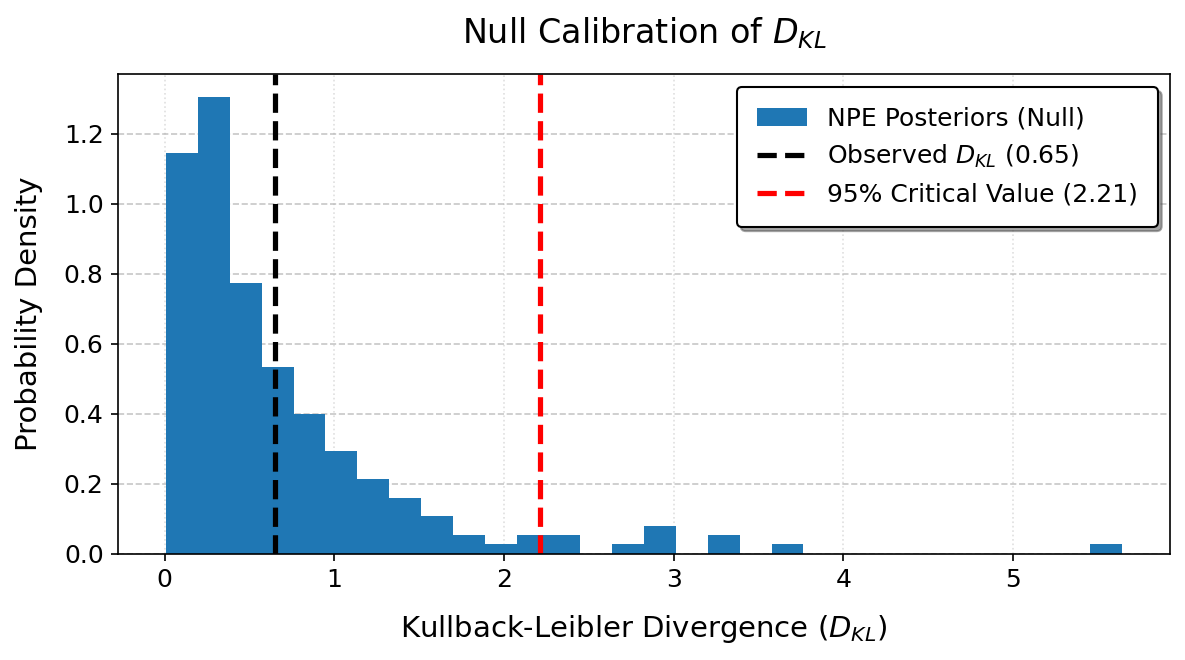

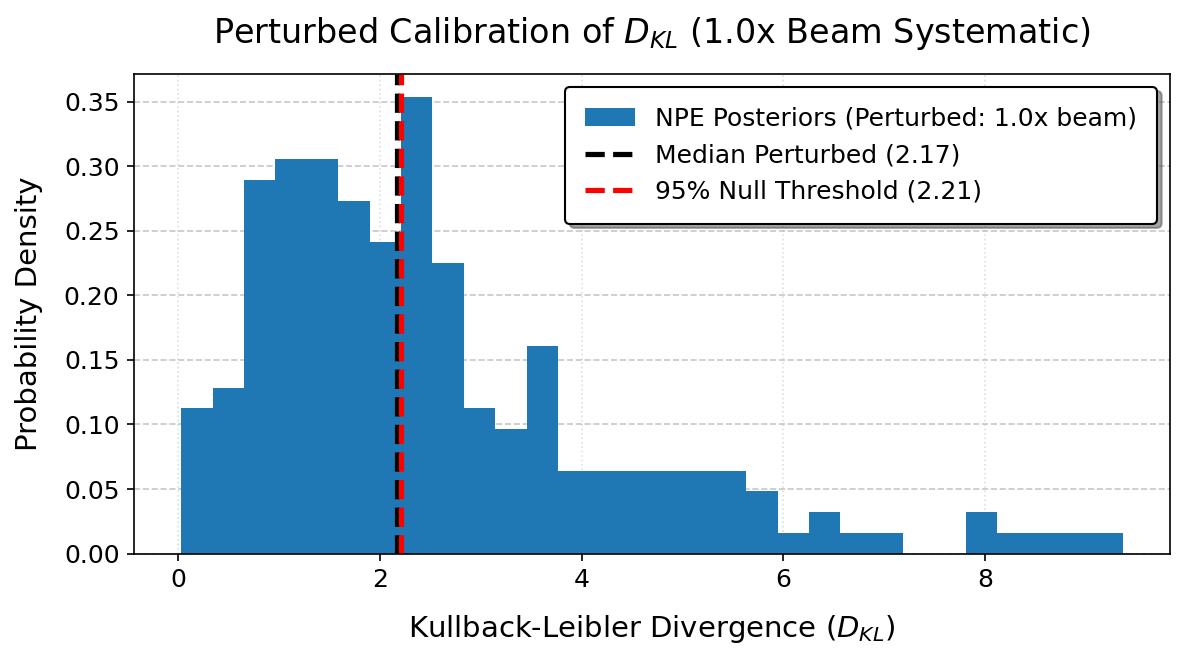

Null 95 percent critical value:      2.21
Perturbed 95 percent critical value: 6.23


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. NULL CALIBRATION GRAPH
# ==========================================
# Plot
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls, bins=30, density=True, color='tab:blue', label='NPE Posteriors (Null)')

plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')

# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()


# ==========================================
# 2. PERTURBED CALIBRATION GRAPH
# ==========================================
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue',
         label=f'NPE Posteriors (Perturbed: {multiplier_val:.1f}x beam)')

# Vertical threshold line (thicker, with dynamic value injected into legend)
plt.axvline(median_perturbed, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Median Perturbed ({median_perturbed:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
            label=f'95% Null Threshold ({crit_val_95:.2f})')

# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(rf"Perturbed Calibration of $D_{{KL}}$ ({multiplier_val:.1f}x Beam Systematic)",
          fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()

# Print statements formatted to 2 decimal places for neatness
print(f"Null 95 percent critical value:      {crit_val_95:.2f}")
print(f"Perturbed 95 percent critical value: {crit_val_95_perturbed:.2f}")
